# <span style= "color:purple"> Cyclic Time Encoding

## <span style= "color:purple"> Toy Example

In [1]:
import numpy as np

# === 1. Generate synthetic data ===
x = np.array([1, 2, 3, 4], dtype=np.float32)
y = np.array([2, 4, 6, 8], dtype=np.float32)

# === 2. Initialize weight and bias randomly ===
w = np.random.randn()
b = np.random.randn()

# === 3. Set learning rate and number of iterations ===
lr = 0.1
epochs = 100

# === 4. Define the prediction and loss function ===
def predict(x):
    return w * x + b

def loss_fn(y_pred, y_true):
    return np.mean((y_pred - y_true)**2)

# === 5. Train with gradient descent ===
for epoch in range(epochs):
    # Forward pass: make prediction
    y_pred = predict(x)

    # Compute loss
    loss = loss_fn(y_pred, y)

    # Compute gradients
    dw = np.mean(2 * x * (y_pred - y))  # derivative w.r.t w
    db = np.mean(2 * (y_pred - y))      # derivative w.r.t b

    # Update parameters
    w -= lr * dw
    b -= lr * db

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

# === 6. Final result ===
print(f"\nLearned weight: {w:.4f}, bias: {b:.4f}")

Epoch 0: Loss=63.5312, w=3.0655, b=2.5753
Epoch 10: Loss=0.4011, w=1.5340, b=1.4743
Epoch 20: Loss=0.2070, w=1.6333, b=1.0801
Epoch 30: Loss=0.1127, w=1.7290, b=0.7969
Epoch 40: Loss=0.0614, w=1.8000, b=0.5880
Epoch 50: Loss=0.0334, w=1.8524, b=0.4339
Epoch 60: Loss=0.0182, w=1.8911, b=0.3202
Epoch 70: Loss=0.0099, w=1.9197, b=0.2362
Epoch 80: Loss=0.0054, w=1.9407, b=0.1743
Epoch 90: Loss=0.0029, w=1.9563, b=0.1286

Learned weight: 1.9667, bias: 0.0978


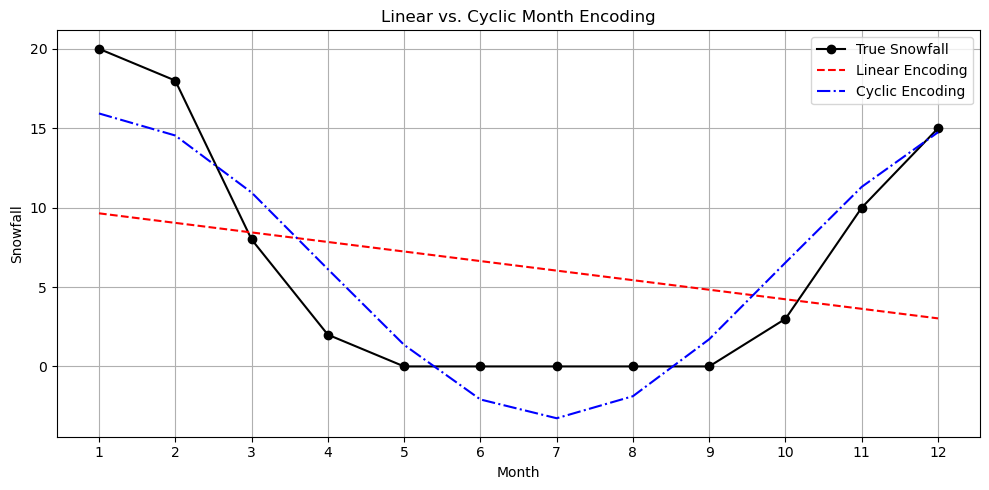

MSE Linear Encoding: 49.41
MSE Cyclic Encoding: 7.65


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ==== 1. Fake snowfall data by month ====
months = np.arange(1, 13)  # 1 to 12
snowfall = np.array([20, 18, 8, 2, 0, 0, 0, 0, 0, 3, 10, 15])  # Fake but realistic pattern

# ==== 2. LINEAR ENCODING ====
X_linear = months.reshape(-1, 1)
model_linear = LinearRegression()
model_linear.fit(X_linear, snowfall)
snow_pred_linear = model_linear.predict(X_linear)

# ==== 3. CYCLIC ENCODING ====
month_angle = 2 * np.pi * (months / 12)
X_cyclic = np.column_stack((np.sin(month_angle), np.cos(month_angle)))
model_cyclic = LinearRegression()
model_cyclic.fit(X_cyclic, snowfall)
snow_pred_cyclic = model_cyclic.predict(X_cyclic)

# ==== 4. PLOT COMPARISON ====
plt.figure(figsize=(10, 5))
plt.plot(months, snowfall, 'ko-', label='True Snowfall')
plt.plot(months, snow_pred_linear, 'r--', label='Linear Encoding')
plt.plot(months, snow_pred_cyclic, 'b-.', label='Cyclic Encoding')
plt.xticks(months)
plt.xlabel('Month')
plt.ylabel('Snowfall')
plt.title('Linear vs. Cyclic Month Encoding')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==== 5. Print errors ====
mse_linear = mean_squared_error(snowfall, snow_pred_linear)
mse_cyclic = mean_squared_error(snowfall, snow_pred_cyclic)
print(f"MSE Linear Encoding: {mse_linear:.2f}")
print(f"MSE Cyclic Encoding: {mse_cyclic:.2f}")